In [1]:
import numpy as np
import os
import cv2

In [2]:
import matplotlib.pyplot as plt

In [3]:
from dep.automated_roi_TK import ImageROIProcessor


In [4]:
path = 'samples/png/'


# files = os.listdir(path)
# # for f in files:
# #     a = np.load(os.path.join(path,f))


# files

# name_to_channels = {}

# for name in files:
#     base_name, channel_part = name.split('_ch_')
#     channel = channel_part.split('.')[0]  # Extract the channel number
#     if base_name not in name_to_channels:
#         name_to_channels[base_name] = []
#     name_to_channels[base_name].append(channel)

# for base_name in name_to_channels:
#     name_to_channels[base_name].sort()
# name_to_channels

In [5]:
# path = 'samples/npy/'


# files = os.listdir(path)
# # for f in files:
# #     a = np.load(os.path.join(path,f))


# files

# name_to_channels = {}

# for name in files:
#     base_name, channel_part = name.split('_ch_')
#     channel = channel_part.split('.')[0]  # Extract the channel number
#     if base_name not in name_to_channels:
#         name_to_channels[base_name] = []
#     name_to_channels[base_name].append(channel)

# for base_name in name_to_channels:
#     name_to_channels[base_name].sort()
# name_to_channels

In [6]:
path = 'samples/npy/'
bf = 'cell-201-01200_INT'
file = bf+'_ch_2.npy'
file

'cell-201-01200_INT_ch_2.npy'

In [7]:
input_path=os.path.join(path,file)
output_path = path
processor = ImageROIProcessor(input_path, output_path, False)

processor.load_image()





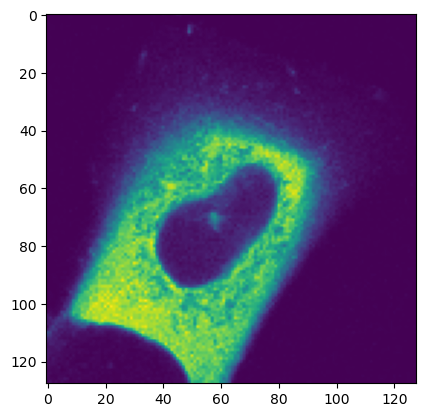

In [8]:
plt.imshow(processor.image)
plt.show()
# plt.imshow(processor.roi_image)

In [19]:
processor.roi_image = processor.detect_cell_roi(processor.image,1.)
# inv = processor.invert_and_apply_mask()
processor.roi_image.max()

255

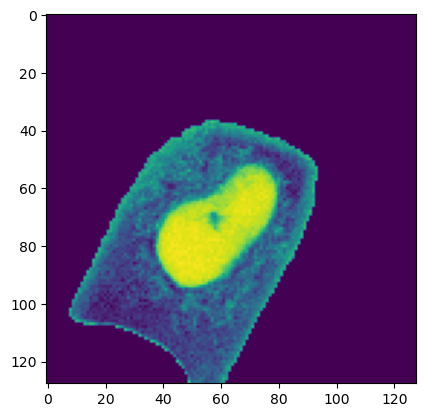

In [10]:
# plt.imshow(processor.image)

plt.imshow(cv2.bitwise_not(processor.image)*(processor.roi_image).astype(int))
# plt.imshow(processor.image,cmap='gray',alpha=0.7)


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


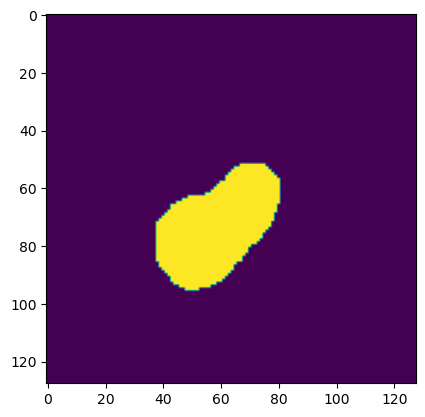

In [11]:
nucleus_roi = processor.detect_nucleus_roi(processor.image,processor.roi_image,1.5)
plt.imshow(nucleus_roi)

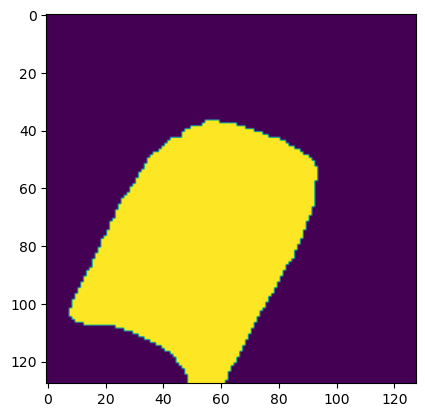

In [12]:

plt.imshow(processor.roi_image)

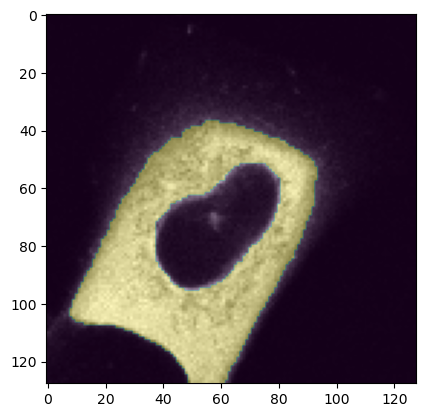

In [15]:
full_mask = processor.make_full_roi(processor.roi_image,nucleus_roi)
plt.imshow(full_mask)
plt.imshow(processor.image,cmap='gray',alpha=0.7)

In [17]:
image_data = np.load(os.path.join('samples/npy/','cell-201-01200_INT_ch_2.npy'))
image_data =(image_data* (255 / image_data.max())).astype(np.uint8)

image_data = cv2.resize(image_data, (500, 500), interpolation=cv2.INTER_CUBIC)/255

image_data

array([[0.        , 0.        , 0.        , ..., 0.00392157, 0.00392157,
        0.00392157],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.00392157,
        0.00392157],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.00392157,
        0.00392157],
       ...,
       [0.01960784, 0.01960784, 0.02745098, ..., 0.00392157, 0.00392157,
        0.00392157],
       [0.01960784, 0.02352941, 0.02745098, ..., 0.00392157, 0.00392157,
        0.00392157],
       [0.01960784, 0.02352941, 0.02745098, ..., 0.00392157, 0.00392157,
        0.00392157]])